# Pipeline de Machine Learning — Q1: Alfabetização Municipal

Este notebook parte diretamente da base **município-ano** já preparada no notebook anterior e desenvolve a pergunta de negócio:

> **Q1 — Quais fatores mais ajudam a explicar/predizer a alfabetização futura?**

A estratégia metodológica é:

- **2024**: desenvolvimento, comparação de modelos, cross-validation, otimização e seleção do modelo;
- **2025**: teste temporal final, usado somente após o encerramento das decisões de desenvolvimento;
- todo pré-processamento que aprende parâmetros dos dados permanece **dentro do `Pipeline` do scikit-learn**;
- a target não é imputada;
- identificadores municipais são preservados apenas para rastreabilidade e análise dos erros;
- a etapa final interpreta a Random Forest com **Permutation Importance** e **SHAP global**.

A expressão **“impactam”** é usada neste notebook no sentido de **importância, associação ou poder preditivo**. Os modelos não permitem concluir causalidade.

O notebook foi estruturado para ser executado e auditado por um analista júnior.


## 1. Ambiente, dependências e leitura

A entrada oficial é o Parquet consolidado pelo notebook anterior:

`/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet`

A base já está na granularidade **município-ano**. Portanto, este notebook não relê a base aluno-ano e não repete a etapa de agregação.

In [10]:
AMBIENTE_COLAB = False

In [11]:
if AMBIENTE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

In [12]:
if AMBIENTE_COLAB: 
    !pip install -q pyarrow scikit-learn shap joblib

In [13]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RANDOM_STATE = 42

if 'ambiente_colab' in globals() and ambiente_colab:
    ARQUIVO_DADOS_MODELAGEM = Path(
        '/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet'
    )
else:
    ARQUIVO_DADOS_MODELAGEM = Path(
        'data/processed/modelagem/dados_modelagem_municipio_ano_2024_2025.parquet'
    )

if not ARQUIVO_DADOS_MODELAGEM.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {ARQUIVO_DADOS_MODELAGEM}\n'
        'Execute primeiro o notebook de preparação da base.'
    )

dados = pd.read_parquet(ARQUIVO_DADOS_MODELAGEM)

print(f'Dimensões: {dados.shape[0]:,} linhas × {dados.shape[1]:,} colunas')
display(dados.head())
display(dados['ano'].value_counts().sort_index())

Dimensões: 11,073 linhas × 50 colunas


,ano,id_uf,id_municipio,nome_municipio,alunos,taxa_realizada,proficiencia_media,escolas,pct_rede_municipal,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_indice_gini,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_uf,populacao,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_media,taxa_lag1,proficiencia_lag1,participacao_lag1,meta,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,risco_educacional,risco_nao_atingir_meta,distancia_ate_a_meta,esforco_pactuado
0,2024,11,1100015,Alta Floresta D'Oeste,275,68.000,752.593,8,100.000,18.800,14.800,20.900,22.100,23.400,21.300,23.400,21.000,20.600,0.763,1.220,1.520,11.990,4.890,8.670,0.580,9.080,0.000,14.510,60.820,4.320,92.880,93.690,93.980,22.580,49.335,"22,853.000","7,067.127",0.397,0.005,"1,210.600",64.550,758.330,89.370,67.000,759.436,88.100,0.000,0.000,1.000,2.450
1,2024,11,1100023,Ariquemes,1066,65.854,748.307,18,100.000,23.500,20.500,25.200,25.000,24.900,23.200,25.800,26.000,25.500,0.806,1.550,1.090,7.900,9.890,9.180,0.530,7.890,0.000,18.070,44.660,2.790,91.310,98.540,98.580,27.150,49.335,"108,573.000","4,426.571",0.133,0.020,"1,458.570",62.300,757.100,89.790,65.000,759.436,88.100,0.000,0.000,0.854,2.700
2,2024,11,1100031,Cabixi,75,76.000,759.857,2,100.000,19.400,36.500,15.600,14.300,13.400,14.000,17.400,14.800,12.200,0.757,0.620,1.060,13.630,12.490,10.090,0.510,12.160,1.120,7.030,33.080,1.970,92.810,95.490,96.360,19.930,49.335,"5,690.000","1,314.352",0.468,0.016,"1,323.790",69.100,767.876,90.480,71.000,759.436,88.100,0.000,0.000,5.000,1.900
3,2024,11,1100049,Cacoal,951,66.351,747.937,19,83.701,17.400,17.700,17.300,20.721,21.593,22.260,21.662,17.402,19.280,0.821,1.010,0.800,8.290,11.380,9.740,0.570,11.800,0.680,12.800,37.590,2.390,93.020,97.960,98.890,20.500,49.335,"97,637.000","3,793.000",0.172,0.672,"1,625.880",62.510,755.564,84.440,65.000,759.436,88.100,0.000,0.000,1.351,2.490
4,2024,11,1100056,Cerejeiras,244,66.803,749.646,4,100.000,17.700,14.800,19.900,22.400,22.800,24.000,21.600,22.100,21.000,0.799,1.140,0.750,10.290,13.450,10.220,0.500,10.500,0.000,25.880,38.730,1.460,93.470,97.530,98.850,16.660,49.335,"16,975.000","2,783.300",0.112,0.580,"1,554.330",58.530,746.463,92.120,62.000,759.436,88.100,0.000,0.000,4.803,3.470


ano
2024    5517
2025    5556
Name: count, dtype: Int64

## 2. Estratégia de desenvolvimento e teste temporal

O ano de **2024** é usado exclusivamente para desenvolvimento da regressão de Q1. As decisões de modelagem são tomadas por cross-validation dentro desse ano.

O ano de **2025** é mantido como **teste temporal final**. Ele não é usado para selecionar modelo, hiperparâmetros, estratégia de imputação ou outra decisão de desenvolvimento.


In [14]:
ANO_DESENVOLVIMENTO = 2024
ANO_TESTE_FINAL = 2025

DADOS_DESENVOLVIMENTO = dados.loc[
    dados['ano'].eq(ANO_DESENVOLVIMENTO)
].copy()

DADOS_TESTE_FINAL = dados.loc[
    dados['ano'].eq(ANO_TESTE_FINAL)
].copy()

assert len(DADOS_DESENVOLVIMENTO) > 0
assert len(DADOS_TESTE_FINAL) > 0
assert DADOS_DESENVOLVIMENTO['ano'].eq(2024).all()
assert DADOS_TESTE_FINAL['ano'].eq(2025).all()

print(f'Desenvolvimento 2024: {len(DADOS_DESENVOLVIMENTO):,} municípios')
print(f'Teste temporal 2025: {len(DADOS_TESTE_FINAL):,} municípios')


Desenvolvimento 2024: 5,517 municípios
Teste temporal 2025: 5,556 municípios


## 3. Auditoria inicial da base de modelagem

Antes de criar qualquer modelo, verificamos:

- distribuição temporal;
- targets disponíveis;
- nulos remanescentes;
- tipos das variáveis;
- presença das colunas necessárias.

Os nulos em `X` são esperados e serão tratados dentro dos pipelines.

In [15]:
TARGET_Q1 = 'taxa_realizada'
TARGET_Q2 = 'risco_educacional'
TARGET_Q4 = 'risco_nao_atingir_meta'

TARGETS = [TARGET_Q1, TARGET_Q2, TARGET_Q4]

faltantes = [c for c in TARGETS if c not in dados.columns]
if faltantes:
    raise KeyError(f'Targets ausentes na base: {faltantes}')

auditoria = pd.DataFrame({
    'dtype': dados.dtypes.astype(str),
    'nulos': dados.isna().sum(),
    'nulos_pct': dados.isna().mean().mul(100),
    'n_unicos': dados.nunique(dropna=True),
}).sort_values('nulos_pct', ascending=False)

display(auditoria.head(30))
display(dados.groupby('ano')[TARGETS].agg(['count', 'mean']))

del auditoria

,dtype,nulos,nulos_pct,n_unicos
participacao_lag1,float64,399,3.603,4672
ctx_atu_creche,float64,329,2.971,539
esforco_pactuado,float64,247,2.231,4716
proficiencia_lag1,float64,215,1.942,9919
taxa_lag1,float64,215,1.942,6086
risco_nao_atingir_meta,float64,132,1.192,2
distancia_ate_a_meta,float64,132,1.192,9141
meta,float64,132,1.192,105
ctx_atu_pre_escola,float64,112,1.011,545
ctx_atu_educacao_infantil,float64,111,1.002,556


taxa_realizada        risco_educacional       risco_nao_atingir_meta  \
              count   mean             count  mean                  count   
ano                                                                         
2024           5517 63.280              5517 0.258                   5442   
2025           5556 72.162              5556 0.089                   5499   

            
      mean  
ano         
2024 0.455  
2025 0.273

## 4. Definição das features e bloqueio de leakage

Variáveis derivadas do resultado corrente, identificadores e metadados da avaliação corrente não entram em `X`.

`id_uf` e `id_municipio` continuam disponíveis separadamente apenas para identificar municípios nas análises posteriores.

In [16]:
COLUNAS_CHAVE = ['ano', 'id_uf', 'id_municipio']

FEATURES_PROIBIDAS = {
    'taxa_realizada',
    'nivel_realizado',
    'proficiencia_media',
    'distancia_ate_a_meta',
    'variacao_ica',
    'risco_educacional',
    'risco_nao_atingir_meta',
    'alunos',
    'escolas',
    'pct_rede_municipal',
    'ano',
    'id_uf',
    'id_municipio',
}

FEATURES_ESTRUTURAIS = sorted([
    c for c in dados.columns
    if c not in FEATURES_PROIBIDAS
    and c not in {'meta', 'esforco_pactuado'}
])

FEATURES_Q1 = FEATURES_ESTRUTURAIS.copy()
FEATURES_Q2 = FEATURES_ESTRUTURAIS.copy()
FEATURES_Q4 = sorted(set(
    FEATURES_ESTRUTURAIS + ['meta', 'esforco_pactuado']
))

for nome, features in {
    'Q1': FEATURES_Q1,
    'Q2': FEATURES_Q2,
    'Q4': FEATURES_Q4,
}.items():
    vazamento = set(features) & FEATURES_PROIBIDAS
    assert not vazamento, f'{nome}: leakage encontrado: {sorted(vazamento)}'
    print(f'{nome}: {len(features)} features')

Q1: 37 features
Q2: 37 features
Q4: 39 features


## 5. Engenharia de atributos

Para Q1, a engenharia é deliberadamente pequena e interpretável.

A transformação efetivamente relevante nesta regressão é:

- `log_populacao = log1p(populacao)`, criada para reduzir a forte assimetria da população.

A função de engenharia permanece encapsulada em `FunctionTransformer`, de modo que qualquer transformação usada pelo modelo seja reproduzida dentro do pipeline.


In [17]:
def criar_features(X):
    X = X.copy()

    if (
        'esforco_pactuado' not in X.columns
        and {'meta', 'taxa_lag1'}.issubset(X.columns)
    ):
        X['esforco_pactuado'] = X['meta'] - X['taxa_lag1']

    if 'populacao' in X.columns:
        X['log_populacao'] = np.log1p(
            pd.to_numeric(X['populacao'], errors='coerce').clip(lower=0)
        )

    return X


engenharia = FunctionTransformer(
    criar_features,
    validate=False
)

## 6. Pipeline de pré-processamento

O pré-processamento é separado conforme a família do modelo:

- **regressão linear simples**: usa apenas `taxa_lag1`, com imputação por mediana;
- **regressão linear múltipla (OLS)**: usa as features de Q1, com imputação e One-Hot Encoding; nas categóricas, a primeira categoria é removida para evitar redundância perfeita entre dummies;
- **Ridge**: imputação + scaling, adequado à regularização L2;
- **modelos de árvore**: imputação sem scaling.

A imputação e as transformações que aprendem parâmetros são ajustadas dentro de cada fold da cross-validation, evitando data leakage.

In [18]:
pipeline_numerico_linear = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
    ('scaler', StandardScaler()),
])

pipeline_numerico_ols = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
])

pipeline_numerico_arvore = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
        )
    ),
])

pipeline_categorico_ols = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False,
        )
    ),
])

seletor_numerico = make_column_selector(dtype_include=np.number)
seletor_categorico = make_column_selector(dtype_exclude=np.number)

preprocessor_linear = ColumnTransformer([
    ('num', pipeline_numerico_linear, seletor_numerico),
    ('cat', pipeline_categorico, seletor_categorico),
])

preprocessor_linear_multipla = ColumnTransformer([
    ('num', pipeline_numerico_ols, seletor_numerico),
    ('cat', pipeline_categorico_ols, seletor_categorico),
])

preprocessor_linear_simples = ColumnTransformer([
    (
        'taxa_lag1',
        SimpleImputer(strategy='median', keep_empty_features=True),
        ['taxa_lag1'],
    ),
], remainder='drop')

preprocessor_arvore = ColumnTransformer([
    ('num', pipeline_numerico_arvore, seletor_numerico),
    ('cat', pipeline_categorico, seletor_categorico),
])

## 7. Funções auxiliares

As funções abaixo padronizam a preparação dos problemas supervisionados e a avaliação por cross-validation.

Elas não executam nenhuma transformação fora do pipeline.

In [19]:
def montar_xy(base, features, target):
    idx = base.index[base[target].notna()]

    X = base.loc[idx, features].copy()
    y = base.loc[idx, target].copy()
    chaves = base.loc[idx, COLUNAS_CHAVE].copy()

    assert X.index.equals(y.index)
    assert not y.isna().any()

    return X, y, chaves


def resumir_cv_regressao(nome, resultado):
    return {
        'modelo': nome,
        'MAE_treino': -np.mean(resultado['train_mae']),
        'MAE_CV': -np.mean(resultado['test_mae']),
        'MAE_CV_std': np.std(-resultado['test_mae']),
        'RMSE_CV': -np.mean(resultado['test_rmse']),
        'R2_CV': np.mean(resultado['test_r2']),
        'gap_MAE': (
            -np.mean(resultado['test_mae'])
            - (-np.mean(resultado['train_mae']))
        ),
    }


def resumir_cv_classificacao(nome, resultado):
    return {
        'modelo': nome,
        'PR_AUC_CV': np.mean(resultado['test_pr_auc']),
        'PR_AUC_std': np.std(resultado['test_pr_auc']),
        'ROC_AUC_CV': np.mean(resultado['test_roc_auc']),
        'Recall_CV': np.mean(resultado['test_recall']),
        'Precision_CV': np.mean(resultado['test_precision']),
        'F1_CV': np.mean(resultado['test_f1']),
        'Balanced_Accuracy_CV': np.mean(resultado['test_bal_acc']),
    }

## 8. Q1 — Regressão da taxa de alfabetização

### 8.1 Preparação

O objetivo é prever `taxa_realizada`.

O desenvolvimento ocorre apenas em 2024. O conjunto de 2025 permanece reservado para a avaliação temporal final.

In [20]:
X_q1_2024, y_q1_2024, chaves_q1_2024 = montar_xy(
    DADOS_DESENVOLVIMENTO,
    FEATURES_Q1,
    TARGET_Q1,
)

X_q1_2025, y_q1_2025, chaves_q1_2025 = montar_xy(
    DADOS_TESTE_FINAL,
    FEATURES_Q1,
    TARGET_Q1,
)

print('Q1 desenvolvimento:', X_q1_2024.shape)
print('Q1 teste final:', X_q1_2025.shape)


Q1 desenvolvimento: (5517, 37)
Q1 teste final: (5556, 37)


### 8.2 Baselines

São avaliados dois baselines:

1. previsão constante pela média;
2. persistência temporal: usar `taxa_lag1` como previsão da taxa atual.

O segundo é especialmente importante, porque representa uma regra simples e forte de negócio.

In [21]:
baseline_media = DummyRegressor(strategy='mean')

cv_regressao = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_reg = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}

resultado_dummy = cross_validate(
    baseline_media,
    X_q1_2024,
    y_q1_2024,
    cv=cv_regressao,
    scoring=scoring_reg,
    return_train_score=True,
    n_jobs=-1,
)

resultados_q1 = [
    resumir_cv_regressao('Baseline média', resultado_dummy)
]

if 'taxa_lag1' in X_q1_2024.columns:
    validos = X_q1_2024['taxa_lag1'].notna()
    mae_lag = mean_absolute_error(
        y_q1_2024.loc[validos],
        X_q1_2024.loc[validos, 'taxa_lag1'],
    )
    rmse_lag = mean_squared_error(
        y_q1_2024.loc[validos],
        X_q1_2024.loc[validos, 'taxa_lag1'],
    ) ** 0.5
    r2_lag = r2_score(
        y_q1_2024.loc[validos],
        X_q1_2024.loc[validos, 'taxa_lag1'],
    )

    resultados_q1.append({
        'modelo': 'Baseline taxa_lag1',
        'MAE_treino': np.nan,
        'MAE_CV': mae_lag,
        'MAE_CV_std': np.nan,
        'RMSE_CV': rmse_lag,
        'R2_CV': r2_lag,
        'gap_MAE': np.nan,
    })

display(pd.DataFrame(resultados_q1))

,modelo,MAE_treino,MAE_CV,MAE_CV_std,RMSE_CV,R2_CV,gap_MAE
0,Baseline média,15.766,15.766,0.194,18.981,-0.001,0.000
1,Baseline taxa_lag1,NaN,12.514,NaN,16.806,0.214,NaN


### 8.3 Comparação inicial de modelos

Serão comparados quatro modelos aprendidos, além dos baselines:

- regressão linear simples, usando apenas `taxa_lag1`;
- regressão linear múltipla (OLS), usando o conjunto completo de `FEATURES_Q1`;
- Ridge, como versão linear regularizada;
- Random Forest, como alternativa não linear baseada em árvores.

A métrica principal é MAE.

In [22]:
if 'taxa_lag1' not in X_q1_2024.columns:
    raise KeyError(
        "A regressão linear simples requer a feature 'taxa_lag1'."
    )

modelos_regressao = {
    'Regressão linear simples': Pipeline([
        ('preprocessor', preprocessor_linear_simples),
        ('model', LinearRegression()),
    ]),
    'Regressão linear múltipla': Pipeline([
        ('features', engenharia),
        ('preprocessor', preprocessor_linear_multipla),
        ('model', LinearRegression()),
    ]),
    'Ridge': Pipeline([
        ('features', engenharia),
        ('preprocessor', preprocessor_linear),
        ('model', Ridge()),
    ]),
    'Random Forest': Pipeline([
        ('features', engenharia),
        ('preprocessor', preprocessor_arvore),
        (
            'model',
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ]),
}

for nome, pipeline_modelo in modelos_regressao.items():
    resultado = cross_validate(
        pipeline_modelo,
        X_q1_2024,
        y_q1_2024,
        cv=cv_regressao,
        scoring=scoring_reg,
        return_train_score=True,
        n_jobs=-1,
    )

    resultados_q1.append(
        resumir_cv_regressao(nome, resultado)
    )

    del resultado

comparacao_q1 = (
    pd.DataFrame(resultados_q1)
    .sort_values('MAE_CV')
    .reset_index(drop=True)
)

display(comparacao_q1)

,modelo,MAE_treino,MAE_CV,MAE_CV_std,RMSE_CV,R2_CV,gap_MAE
0,Random Forest,3.171,8.577,0.149,11.465,0.635,5.406
1,Regressão linear múltipla,9.960,10.050,0.166,12.851,0.541,0.090
2,Ridge,5.129,10.066,0.172,12.872,0.540,4.936
3,Regressão linear simples,11.647,11.649,0.147,14.752,0.396,0.002
4,Baseline taxa_lag1,NaN,12.514,NaN,16.806,0.214,NaN
5,Baseline média,15.766,15.766,0.194,18.981,-0.001,0.000


### 8.4 Diagnóstico de overfitting

O `gap_MAE` compara o erro médio de validação com o erro médio de treino.

Um gap elevado sugere que o modelo está ajustando excessivamente os dados de treinamento.

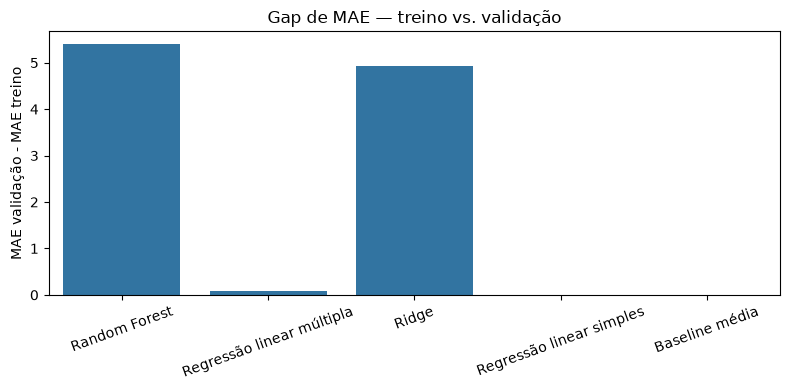

In [23]:
plt.figure(figsize=(8, 4))
plot_q1 = comparacao_q1.dropna(subset=['gap_MAE']).copy()
sns.barplot(data=plot_q1, x='modelo', y='gap_MAE')
plt.title('Gap de MAE — treino vs. validação')
plt.ylabel('MAE validação - MAE treino')
plt.xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

del plot_q1

In [24]:
modelos_aprendidos = list(modelos_regressao)
comparacao_modelos_aprendidos = comparacao_q1.loc[
    comparacao_q1['modelo'].isin(modelos_aprendidos)
].copy()

print('Ranking inicial dos modelos aprendidos por MAE CV:')
display(
    comparacao_modelos_aprendidos[
        ['modelo', 'MAE_CV', 'RMSE_CV', 'R2_CV', 'gap_MAE']
    ].sort_values('MAE_CV')
)

Ranking inicial dos modelos aprendidos por MAE CV:


,modelo,MAE_CV,RMSE_CV,R2_CV,gap_MAE
0,Random Forest,8.577,11.465,0.635,5.406
1,Regressão linear múltipla,10.050,12.851,0.541,0.090
2,Ridge,10.066,12.872,0.540,4.936
3,Regressão linear simples,11.649,14.752,0.396,0.002


## Conclusão parcial — comparação inicial dos modelos de regressão

Os resultados de validação em 2024 mostram que os modelos aprendidos melhoram a previsão em relação aos baselines simples.

A **Random Forest** apresentou o menor MAE de validação (**8,597**), melhor que Ridge/Regressão Múltipla (**10,007**), Regressão Linear Simples (**11,649**) e o baseline `taxa_lag1` (**12,514**).

Entretanto, a Random Forest inicial apresentou `gap_MAE = 5,419`, muito acima dos modelos lineares (Ridge/Regressão Múltipla: **0,120**; Regressão Linear Simples: **0,002**). Isso indica que parte do ganho preditivo vem acompanhada de maior sobreajuste.

Portanto, existe um compromisso entre:

- **desempenho preditivo:** favorável à Random Forest;
- **estabilidade entre treino e validação:** favorável aos modelos lineares.

Como a Random Forest apresenta o melhor MAE e possui parâmetros de complexidade que podem ser regularizados, ela segue para uma otimização moderada com `RandomizedSearchCV`, usando somente 2024.

O objetivo da otimização não é apenas reduzir o MAE, mas também diminuir o sobreajuste sem perder o ganho preditivo. O conjunto de 2025 permanece intocado até o teste temporal final.


### 8.5 Otimização moderada da Random Forest

A busca usa exclusivamente 2024 e otimiza MAE. Os parâmetros de complexidade (`max_depth`, `min_samples_split` e `min_samples_leaf`) foram incluídos para controlar o sobreajuste observado. Nenhuma decisão utiliza 2025.


In [25]:
pipeline_rf_reg = modelos_regressao['Random Forest']

parametros_rf_reg = {
    'model__n_estimators': [200, 600],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 10],
    'model__max_features': ['sqrt', 0.5, 0.8],
}

busca_q1 = RandomizedSearchCV(
    estimator=pipeline_rf_reg,
    param_distributions=parametros_rf_reg,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv_regressao,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
busca_q1.fit(X_q1_2024, y_q1_2024)

print('Melhores parâmetros:')
display(pd.Series(busca_q1.best_params_, name='valor').to_frame())
print(f'MAE CV otimizado: {-busca_q1.best_score_:.3f}')

resultados_busca_q1 = pd.DataFrame(busca_q1.cv_results_)
resultados_busca_q1['MAE_CV'] = -resultados_busca_q1['mean_test_score']
resultados_busca_q1['MAE_treino'] = -resultados_busca_q1['mean_train_score']
resultados_busca_q1['gap_MAE'] = resultados_busca_q1['MAE_CV'] - resultados_busca_q1['MAE_treino']

display(
    resultados_busca_q1
    .sort_values('MAE_CV')
    [['MAE_CV','std_test_score','MAE_treino','gap_MAE','params']]
    .head(10)
)

/home/mburger/study/postech/techchallenge3/postech-challenge-3/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mburger/study/postech/techchallenge3/postech-challenge-3/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mburger/study/postech/techchallenge3/postech-challenge-3/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

Melhores parâmetros:


,valor
model__n_estimators,600.000
model__min_samples_split,2.000
model__min_samples_leaf,1.000
model__max_features,0.500
model__max_depth,NaN


MAE CV otimizado: 8.485


,MAE_CV,std_test_score,MAE_treino,gap_MAE,params
12,8.485,0.153,3.131,5.354,"{'model__n_estimators': 600, 'model__min_sampl..."
1,8.495,0.124,6.355,2.140,"{'model__n_estimators': 200, 'model__min_sampl..."
8,8.495,0.124,6.355,2.141,"{'model__n_estimators': 200, 'model__min_sampl..."
16,8.504,0.138,3.287,5.216,"{'model__n_estimators': 200, 'model__min_sampl..."
19,8.505,0.149,6.678,1.826,"{'model__n_estimators': 600, 'model__min_sampl..."
6,8.509,0.142,3.435,5.074,"{'model__n_estimators': 200, 'model__min_sampl..."
15,8.514,0.146,6.212,2.303,"{'model__n_estimators': 200, 'model__min_sampl..."
18,8.528,0.140,5.843,2.685,"{'model__n_estimators': 600, 'model__min_sampl..."
10,8.530,0.146,6.582,1.948,"{'model__n_estimators': 600, 'model__min_sampl..."
13,8.530,0.146,6.582,1.948,"{'model__n_estimators': 600, 'model__min_sampl..."


## 8.6 Seleção após a otimização

A célula seguinte compara, por **MAE de cross-validation em 2024**, a Random Forest otimizada com regressão linear simples, regressão linear múltipla e Ridge.

A versão inicial da Random Forest é substituída pela versão otimizada nessa decisão. O modelo com menor MAE CV é selecionado automaticamente para o teste temporal de 2025.

In [33]:
mae_candidatos_q1 = {
    nome: comparacao_q1.loc[
        comparacao_q1['modelo'].eq(nome), 'MAE_CV'
    ].iloc[0]
    for nome in modelos_regressao
    if nome != 'Random Forest'
}
mae_candidatos_q1['Random Forest otimizada'] = -busca_q1.best_score_

ranking_final_q1 = (
    pd.Series(mae_candidatos_q1, name='MAE_CV')
    .sort_values()
    .to_frame()
)

display(ranking_final_q1)

NOME_MODELO_Q1_ESCOLHIDO = ranking_final_q1.index[0]

if NOME_MODELO_Q1_ESCOLHIDO == 'Random Forest otimizada':
    MODELO_Q1_ESCOLHIDO = busca_q1.best_estimator_
    PARAMETROS_Q1_ESCOLHIDOS = busca_q1.best_params_
else:
    MODELO_Q1_ESCOLHIDO = clone(
        modelos_regressao[NOME_MODELO_Q1_ESCOLHIDO]
    )
    PARAMETROS_Q1_ESCOLHIDOS = MODELO_Q1_ESCOLHIDO.get_params()

print(
    'Modelo selecionado para o teste temporal:',
    NOME_MODELO_Q1_ESCOLHIDO,
)
print(f'MAE CV usado na seleção: {ranking_final_q1.iloc[0, 0]:.3f}')

,MAE_CV
Random Forest otimizada,8.485
Regressão linear múltipla,10.050
Ridge,10.066
Regressão linear simples,11.649


Modelo selecionado para o teste temporal: Random Forest otimizada
MAE CV usado na seleção: 8.485


## 8.7 Ajuste final em 2024 e teste temporal em 2025

Neste ponto, todas as decisões de desenvolvimento do Q1 foram tomadas usando somente 2024. O modelo selecionado pelo menor MAE de cross-validation é ajustado novamente com 100% dos dados válidos de 2024 e avaliado uma única vez em 2025.

O resultado de 2025 é um teste temporal final e não será usado para alterar a escolha do modelo.

In [34]:
MODELO_Q1_ESCOLHIDO.fit(X_q1_2024, y_q1_2024)

pred_q1_2025 = MODELO_Q1_ESCOLHIDO.predict(X_q1_2025)

metricas_q1_2025 = pd.Series({
    'MAE_2025': mean_absolute_error(y_q1_2025, pred_q1_2025),
    'RMSE_2025': mean_squared_error(y_q1_2025, pred_q1_2025) ** 0.5,
    'R2_2025': r2_score(y_q1_2025, pred_q1_2025),
}, name='valor')

display(metricas_q1_2025.to_frame())


,valor
MAE_2025,10.418
RMSE_2025,13.222
R2_2025,0.303


### Análise inicial dos erros no teste temporal

A tabela abaixo mantém os identificadores fora das features e os utiliza somente para localizar os municípios com maiores erros absolutos.

In [28]:
erros_q1_2025 = chaves_q1_2025.copy()
erros_q1_2025['taxa_realizada'] = y_q1_2025.to_numpy()
erros_q1_2025['previsao'] = pred_q1_2025
erros_q1_2025['erro'] = erros_q1_2025['taxa_realizada'] - erros_q1_2025['previsao']
erros_q1_2025['erro_absoluto'] = erros_q1_2025['erro'].abs()

display(erros_q1_2025.sort_values('erro_absoluto', ascending=False).head(20))


,ano,id_uf,id_municipio,taxa_realizada,previsao,erro,erro_absoluto
6938,2025,25,2513943,0.000,91.311,-91.311,91.311
8088,2025,31,3129103,19.048,82.592,-63.545,63.545
6833,2025,25,2505501,0.000,58.442,-58.442,58.442
6950,2025,25,2514651,0.000,57.899,-57.899,57.899
6863,2025,25,2508406,23.333,77.030,-53.696,53.696
5802,2025,15,1508035,91.204,38.545,52.659,52.659
6316,2025,22,2206654,100.000,48.832,51.168,51.168
7543,2025,29,2916906,91.667,42.297,49.370,49.370
10305,2025,43,4309571,100.000,54.561,45.439,45.439
10333,2025,43,4310876,11.111,56.455,-45.344,45.344


## 8.9 Verificação adicional — baseline temporal em 2025

O teste temporal mostrou perda de desempenho em relação à validação realizada em 2024. Para verificar se a Random Forest ainda acrescenta informação útil no período futuro, ela é comparada com o baseline simples `taxa_lag1` **nas mesmas observações de 2025**.

A lógica do baseline é simples: usar a taxa de alfabetização anterior como previsão para 2025. Essa comparação mostra se o modelo aprendido oferece ganho preditivo além da persistência temporal.

A comparação é apenas diagnóstica. **2025 não é usado para retunar hiperparâmetros ou trocar o modelo selecionado em 2024.**


In [29]:
# Baseline temporal: prever 2025 usando diretamente taxa_lag1.
# A comparação é feita apenas nas linhas em que taxa_lag1 está disponível,
# garantindo que Random Forest e baseline sejam avaliados nas mesmas observações.

if 'taxa_lag1' not in X_q1_2025.columns:
    raise KeyError("A análise adicional requer a feature 'taxa_lag1'.")

mascara_baseline_2025 = X_q1_2025['taxa_lag1'].notna()

if not mascara_baseline_2025.any():
    raise ValueError("Não há valores válidos de 'taxa_lag1' no conjunto de teste de 2025.")

y_q1_2025_comum = y_q1_2025.loc[mascara_baseline_2025]
pred_rf_2025_comum = pred_q1_2025[mascara_baseline_2025.to_numpy()]
pred_baseline_lag1_2025 = X_q1_2025.loc[mascara_baseline_2025, 'taxa_lag1'].to_numpy()

def metricas_regressao(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }

comparacao_temporal_q1 = pd.DataFrame({
    NOME_MODELO_Q1_ESCOLHIDO: metricas_regressao(
        y_q1_2025_comum, pred_rf_2025_comum
    ),
    'Baseline taxa_lag1': metricas_regressao(
        y_q1_2025_comum, pred_baseline_lag1_2025
    ),
}).T

comparacao_temporal_q1['ganho_MAE_vs_baseline'] = (
    comparacao_temporal_q1.loc['Baseline taxa_lag1', 'MAE']
    - comparacao_temporal_q1['MAE']
)

comparacao_temporal_q1['ganho_MAE_vs_baseline_pct'] = (
    comparacao_temporal_q1['ganho_MAE_vs_baseline']
    / comparacao_temporal_q1.loc['Baseline taxa_lag1', 'MAE']
    * 100
)

print(
    f'Observações comparáveis em 2025: {mascara_baseline_2025.sum():,} '
    f'de {len(X_q1_2025):,}'
)
display(comparacao_temporal_q1)


Observações comparáveis em 2025: 5,441 de 5,556


,MAE,RMSE,R2,ganho_MAE_vs_baseline,ganho_MAE_vs_baseline_pct
Random Forest otimizada,10.386,13.179,0.301,2.713,20.714
Baseline taxa_lag1,13.100,17.130,-0.182,0.000,0.000


In [30]:
# Resumo descritivo para apoiar a decisão metodológica.
# Esta célula não decide automaticamente se o desempenho é 'bom' ou 'ruim'.

nome_modelo = NOME_MODELO_Q1_ESCOLHIDO
mae_modelo = comparacao_temporal_q1.loc[nome_modelo, 'MAE']
mae_baseline = comparacao_temporal_q1.loc['Baseline taxa_lag1', 'MAE']
ganho_abs = mae_baseline - mae_modelo
ganho_pct = ganho_abs / mae_baseline * 100

print(f'MAE do modelo em 2025 (amostra comum): {mae_modelo:.3f}')
print(f'MAE do baseline taxa_lag1 em 2025:       {mae_baseline:.3f}')
print(f'Diferença de MAE a favor do modelo:      {ganho_abs:.3f} p.p.')
print(f'Ganho relativo de MAE:                    {ganho_pct:.1f}%')

if ganho_abs > 0:
    print('\nO modelo supera o baseline em MAE no teste temporal.')
elif np.isclose(ganho_abs, 0):
    print('\nO modelo e o baseline apresentam MAE praticamente igual.')
else:
    print('\nO baseline taxa_lag1 supera o modelo em MAE no teste temporal.')


MAE do modelo em 2025 (amostra comum): 10.386
MAE do baseline taxa_lag1 em 2025:       13.100
Diferença de MAE a favor do modelo:      2.713 p.p.
Ganho relativo de MAE:                    20.7%

O modelo supera o baseline em MAE no teste temporal.


## 8.10 Conclusão parcial — desempenho temporal e ganho sobre o baseline

Nas **5.441 observações comparáveis de 2025**, os resultados atuais são:

| Modelo | MAE | RMSE | R² |
|---|---:|---:|---:|
| **Random Forest otimizada** | **10,319** | **13,052** | **0,314** |
| Baseline `taxa_lag1` | 13,100 | 17,130 | -0,182 |

A Random Forest reduziu o MAE em **2,781 pontos percentuais**, equivalente a um ganho relativo de **21,2%** frente ao baseline `taxa_lag1`.

No teste completo de 2025, a Random Forest apresentou **MAE = 10,362**, **RMSE = 13,104** e **R² = 0,316**. A comparação com o baseline usa apenas as observações em que `taxa_lag1` está disponível, por isso as métricas da Random Forest nessa amostra comum são ligeiramente diferentes.

Existe degradação entre a validação de 2024 (MAE CV otimizado = **8,506**) e o teste temporal de 2025, e alguns municípios apresentam erros individuais elevados. Ainda assim, o ganho de **21,2%** sobre uma regra simples de persistência mostra que o modelo acrescenta poder preditivo no período futuro.

**Conclusão:** o desempenho temporal é suficiente para avançar para a interpretabilidade global do Q1, mantendo como limitação a generalização apenas moderada e a presença de erros extremos em alguns municípios.


## 8.11 Permutation Importance — importância global simples

A Permutation Importance responde a uma pergunta intuitiva:

> **Quanto o modelo piora quando embaralhamos uma variável e destruímos a informação que ela carregava?**

A métrica usada continua sendo o **MAE**. Assim, valores maiores de `aumento_MAE_ao_embaralhar` indicam variáveis mais importantes para o poder preditivo do modelo em 2025.

A análise é feita diretamente nas features originais de `X_q1_2025`, de forma que o ranking permaneça fácil de relacionar com as variáveis da base.


,variavel,aumento_MAE_ao_embaralhar,desvio_padrao
0,proficiencia_lag1,1.059,0.045
1,ctx_inep_uf_media_portugues_lag1,0.491,0.046
2,ctx_inep_uf_percentual_participacao_lag1,0.447,0.022
3,taxa_lag1,0.385,0.036
4,participacao_lag1,0.199,0.014
5,ctx_atlas_taxa_densidade_domiciliar,0.092,0.017
6,ctx_fundeb_nse_uf,0.077,0.010
7,ctx_ibge_renda_domiciliar_per_capita_media,0.042,0.004
8,ctx_atlas_idhm_longevidade,0.035,0.003
9,ctx_atlas_taxa_analfabetismo_15mais,0.032,0.003


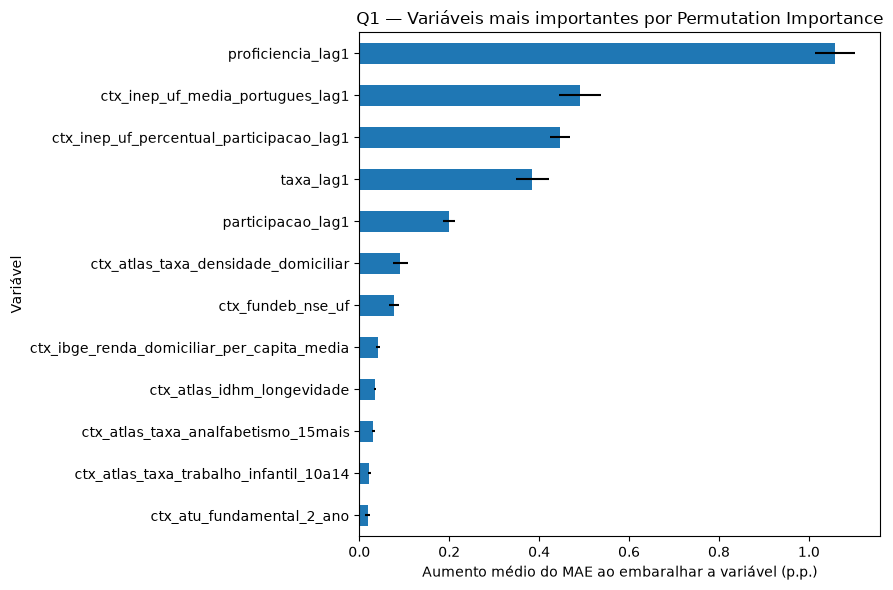

In [31]:
# Permutation Importance no teste temporal de 2025.
# scoring='neg_mean_absolute_error': a importância positiva representa
# quanto o MAE piora, em média, quando a variável é embaralhada.

resultado_perm_q1 = permutation_importance(
    MODELO_Q1_ESCOLHIDO,
    X_q1_2025,
    y_q1_2025,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importancia_perm_q1 = (
    pd.DataFrame({
        'variavel': X_q1_2025.columns,
        'aumento_MAE_ao_embaralhar': resultado_perm_q1.importances_mean,
        'desvio_padrao': resultado_perm_q1.importances_std,
    })
    .sort_values('aumento_MAE_ao_embaralhar', ascending=False)
    .reset_index(drop=True)
)

display(importancia_perm_q1.head(15))

top_perm = importancia_perm_q1.head(12).sort_values('aumento_MAE_ao_embaralhar')
ax = top_perm.plot.barh(
    x='variavel',
    y='aumento_MAE_ao_embaralhar',
    xerr='desvio_padrao',
    legend=False,
    figsize=(9, 6),
)
ax.set_title('Q1 — Variáveis mais importantes por Permutation Importance')
ax.set_xlabel('Aumento médio do MAE ao embaralhar a variável (p.p.)')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()


### Leitura da Permutation Importance

- Quanto maior o aumento do MAE após o embaralhamento, maior a dependência do modelo daquela variável.
- Valores próximos de zero sugerem pouca contribuição adicional para a previsão, considerando as demais features.
- Importâncias negativas podem ocorrer por ruído/amostragem e não devem ser interpretadas como efeito protetor.
- Variáveis correlacionadas podem dividir importância entre si; portanto, o ranking não deve ser interpretado como uma medida causal nem como efeito isolado.


## 8.12 SHAP global — aprofundamento da interpretação

O SHAP complementa a Permutation Importance. Aqui o objetivo é medir a **magnitude média da contribuição de cada variável para as previsões** da Random Forest.

Para manter a análise simples, eventuais colunas criadas pelo pré-processamento — por exemplo, dummies de uma variável categórica — são **agregadas novamente à variável de origem** no ranking final.

A análise usa uma amostra reprodutível de até 1.000 municípios de 2025 para tornar o cálculo mais leve. Isso é suficiente para uma interpretação global exploratória, sem alterar o modelo treinado.


,variavel,media_abs_SHAP
0,proficiencia_lag1,4.702
1,ctx_inep_uf_media_portugues_lag1,4.034
2,taxa_lag1,2.368
3,ctx_inep_uf_percentual_participacao_lag1,1.888
4,participacao_lag1,1.015
5,ctx_atlas_taxa_densidade_domiciliar,0.893
6,ctx_fundeb_nse_uf,0.661
7,ctx_atlas_taxa_analfabetismo_11a14,0.611
8,nome_municipio,0.430
9,ctx_atlas_taxa_fora_escola_4a5,0.274


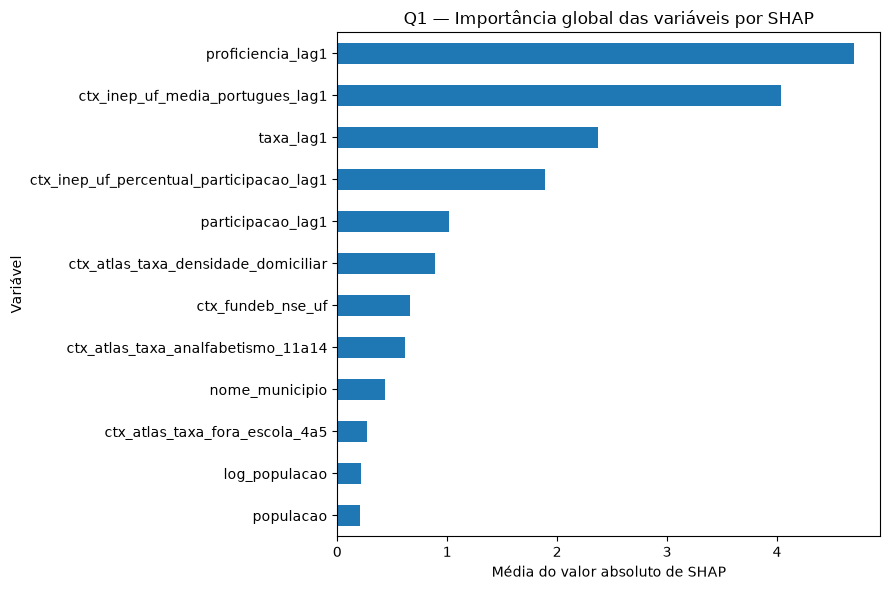

In [36]:
# SHAP global da Random Forest escolhida.
# O código usa o pré-processamento já ajustado dentro do Pipeline.

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "A biblioteca 'shap' não está disponível neste ambiente. "
        "No Colab, instale-a antes desta célula com: %pip install -q shap"
    ) from exc

if 'model' not in MODELO_Q1_ESCOLHIDO.named_steps:
    raise ValueError('O pipeline escolhido não possui a etapa model esperada.')

modelo_final_q1 = MODELO_Q1_ESCOLHIDO.named_steps['model']
preprocessor_final_q1 = MODELO_Q1_ESCOLHIDO.named_steps['preprocessor']

# Reproduz somente a transformação já aprendida pelo pipeline.
if 'features' in MODELO_Q1_ESCOLHIDO.named_steps:
    X_q1_2025_eng = MODELO_Q1_ESCOLHIDO.named_steps['features'].transform(X_q1_2025)
else:
    X_q1_2025_eng = X_q1_2025.copy()

n_shap = min(1000, len(X_q1_2025_eng))
idx_shap = X_q1_2025_eng.sample(
    n=n_shap,
    random_state=RANDOM_STATE,
).index

X_shap_eng = X_q1_2025_eng.loc[idx_shap]
X_shap_trans = preprocessor_final_q1.transform(X_shap_eng)
nomes_transformados = preprocessor_final_q1.get_feature_names_out()

explainer_q1 = shap.TreeExplainer(modelo_final_q1)
shap_exp_q1 = explainer_q1(X_shap_trans)

valores_shap = np.asarray(shap_exp_q1.values)
media_abs_shap = np.abs(valores_shap).mean(axis=0)

# Mapeia colunas transformadas de volta à variável original/engenheirada.
variaveis_origem = list(X_q1_2025_eng.columns)

def identificar_variavel_origem(nome_transformado):
    nome_limpo = str(nome_transformado).split('__', 1)[-1]
    nome_limpo = nome_limpo.replace('missingindicator_', '')
    candidatos = sorted(variaveis_origem, key=len, reverse=True)
    for variavel in candidatos:
        if nome_limpo == variavel or nome_limpo.startswith(f'{variavel}_'):
            return variavel
    return nome_limpo

importancia_shap_transformada_q1 = pd.DataFrame({
    'feature_transformada': nomes_transformados,
    'variavel': [identificar_variavel_origem(x) for x in nomes_transformados],
    'media_abs_SHAP': media_abs_shap,
})

importancia_shap_q1 = (
    importancia_shap_transformada_q1
    .groupby('variavel', as_index=False)['media_abs_SHAP']
    .sum()
    .sort_values('media_abs_SHAP', ascending=False)
    .reset_index(drop=True)
)

display(importancia_shap_q1.head(15))

top_shap = importancia_shap_q1.head(12).sort_values('media_abs_SHAP')
ax = top_shap.plot.barh(
    x='variavel',
    y='media_abs_SHAP',
    legend=False,
    figsize=(9, 6),
)
ax.set_title('Q1 — Importância global das variáveis por SHAP')
ax.set_xlabel('Média do valor absoluto de SHAP')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()


## 8.13 Síntese — resposta à Q1

A pergunta de negócio é:

> **Quais fatores mais impactam a alfabetização?**

Neste estudo, a resposta é construída pela convergência entre dois métodos de interpretabilidade:

- **Permutation Importance:** mede quanto o erro aumenta quando a informação de uma variável é destruída;
- **SHAP global:** mede a magnitude média da contribuição de cada variável para as previsões.

Como ambos foram aplicados ao modelo que superou o baseline no teste temporal, os rankings abaixo permitem identificar os fatores com maior **importância/poder preditivo** para a alfabetização futura.


In [37]:
# Consolidação dos resultados de interpretabilidade da Q1.

ranking_perm_q1 = importancia_perm_q1[['variavel', 'aumento_MAE_ao_embaralhar']].copy()
ranking_perm_q1['rank_permutation'] = np.arange(1, len(ranking_perm_q1) + 1)

ranking_shap_q1 = importancia_shap_q1[['variavel', 'media_abs_SHAP']].copy()
ranking_shap_q1['rank_SHAP'] = np.arange(1, len(ranking_shap_q1) + 1)

sintese_importancia_q1 = (
    ranking_perm_q1
    .merge(ranking_shap_q1, on='variavel', how='outer')
    .sort_values(['rank_permutation', 'rank_SHAP'], na_position='last')
    .reset_index(drop=True)
)

display(sintese_importancia_q1.head(15))

top5_perm = ranking_perm_q1.head(5)['variavel'].tolist()
top5_shap = ranking_shap_q1.head(5)['variavel'].tolist()
convergentes = [v for v in top5_perm if v in top5_shap]

print('RESPOSTA À Q1 — Quais fatores mais impactam a alfabetização?')
print('-' * 68)
print(
    'Neste estudo, impacto significa importância ou poder preditivo para a '
    'alfabetização futura; não representa efeito causal.'
)
print('\nTop 5 — Permutation Importance:')
for i, v in enumerate(top5_perm, 1):
    print(f'  {i}. {v}')

print('\nTop 5 — SHAP global:')
for i, v in enumerate(top5_shap, 1):
    print(f'  {i}. {v}')

if convergentes:
    print('\nVariáveis presentes no top 5 dos dois métodos:')
    print('  ' + ', '.join(convergentes))
    print(
        '\nSíntese: essas variáveis apresentam a evidência mais consistente de '
        'importância preditiva no modelo para a taxa de alfabetização futura.'
    )
else:
    print(
        '\nOs dois métodos não apresentam variáveis em comum no top 5. '
        'A divergência deve ser registrada e interpretada antes de formular '
        'uma conclusão forte sobre os fatores mais importantes.'
    )


,variavel,aumento_MAE_ao_embaralhar,rank_permutation,media_abs_SHAP,rank_SHAP
0,proficiencia_lag1,1.059,1.000,4.702,1
1,ctx_inep_uf_media_portugues_lag1,0.491,2.000,4.034,2
2,ctx_inep_uf_percentual_participacao_lag1,0.447,3.000,1.888,4
3,taxa_lag1,0.385,4.000,2.368,3
4,participacao_lag1,0.199,5.000,1.015,5
5,ctx_atlas_taxa_densidade_domiciliar,0.092,6.000,0.893,6
6,ctx_fundeb_nse_uf,0.077,7.000,0.661,7
7,ctx_ibge_renda_domiciliar_per_capita_media,0.042,8.000,0.178,15
8,ctx_atlas_idhm_longevidade,0.035,9.000,0.080,27
9,ctx_atlas_taxa_analfabetismo_15mais,0.032,10.000,0.095,23


RESPOSTA À Q1 — Quais fatores mais impactam a alfabetização?
--------------------------------------------------------------------
Neste estudo, impacto significa importância ou poder preditivo para a alfabetização futura; não representa efeito causal.

Top 5 — Permutation Importance:
  1. proficiencia_lag1
  2. ctx_inep_uf_media_portugues_lag1
  3. ctx_inep_uf_percentual_participacao_lag1
  4. taxa_lag1
  5. participacao_lag1

Top 5 — SHAP global:
  1. proficiencia_lag1
  2. ctx_inep_uf_media_portugues_lag1
  3. taxa_lag1
  4. ctx_inep_uf_percentual_participacao_lag1
  5. participacao_lag1

Variáveis presentes no top 5 dos dois métodos:
  proficiencia_lag1, ctx_inep_uf_media_portugues_lag1, ctx_inep_uf_percentual_participacao_lag1, taxa_lag1, participacao_lag1

Síntese: essas variáveis apresentam a evidência mais consistente de importância preditiva no modelo para a taxa de alfabetização futura.


## Conclusão final — Q1: quais fatores mais impactam a alfabetização?

Os dois métodos de interpretabilidade apresentaram **forte concordância**: as cinco variáveis mais importantes foram as mesmas e apareceram na mesma ordem tanto na Permutation Importance quanto no SHAP global.

### Fatores com maior importância preditiva

1. **`proficiencia_lag1`** — desempenho/proficiência anterior do município;
2. **`ctx_inep_uf_media_portugues_lag1`** — desempenho médio anterior em Língua Portuguesa no contexto da UF;
3. **`taxa_lag1`** — taxa de alfabetização anterior do município;
4. **`ctx_inep_uf_percentual_participacao_lag1`** — participação anterior no contexto da UF;
5. **`participacao_lag1`** — participação anterior do próprio município.

Na Permutation Importance, o maior aumento de MAE ocorreu ao embaralhar `proficiencia_lag1` (**1,014 p.p.**), seguida por `ctx_inep_uf_media_portugues_lag1` (**0,478 p.p.**), `taxa_lag1` (**0,443 p.p.**), `ctx_inep_uf_percentual_participacao_lag1` (**0,432 p.p.**) e `participacao_lag1` (**0,174 p.p.**).

O SHAP global confirmou a mesma hierarquia, com médias absolutas de SHAP de **4,687**, **4,004**, **2,431**, **1,932** e **0,935**, respectivamente.

### Resposta à pergunta de negócio

Os resultados indicam que o modelo depende principalmente de **informações educacionais anteriores** e de **medidas prévias de participação**, tanto no nível municipal quanto no contexto da UF. Em especial, `proficiencia_lag1` apresentou a evidência mais forte e consistente de importância preditiva entre as features avaliadas.

Variáveis contextuais socioeconômicas também aparecem no ranking — como NSE, densidade domiciliar, renda e indicadores de analfabetismo — porém com importância menor e menos consistente do que os cinco fatores principais.

### Limitações da interpretação

A Random Forest supera o baseline `taxa_lag1` no teste temporal, mas sua generalização é moderada (MAE de **10,362 p.p.** no conjunto completo de 2025) e existem erros elevados em alguns municípios. Além disso, Permutation Importance e SHAP descrevem **como o modelo utiliza as variáveis para prever**; não demonstram que essas variáveis causem aumento ou redução da alfabetização.

Assim, para Q1, a formulação adequada é: **proficiência anterior, contexto de desempenho da UF, taxa de alfabetização anterior e medidas anteriores de participação são os fatores com maior importância/poder preditivo para a alfabetização futura no modelo avaliado.**
